In [1]:
## libraries to install ##
#!pip install seaborn pandas matplotlib numpy tabulate plotly

import os
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from hbn.visualization import visualize as vis, raw_scores
from hbn.visualization import utils as utils
from hbn.constants import Defaults

import plotly.io as pio
pio.renderers.default='notebook'

import warnings
warnings.filterwarnings('ignore')

%load_ext autoreload
%autoreload 2

In [2]:
# load data
release = 'Release11_Apr2024'
df = pd.read_csv(os.path.join(Defaults.INTERIM_FEATURES_DIR, release, 'participant_train_test.csv'))

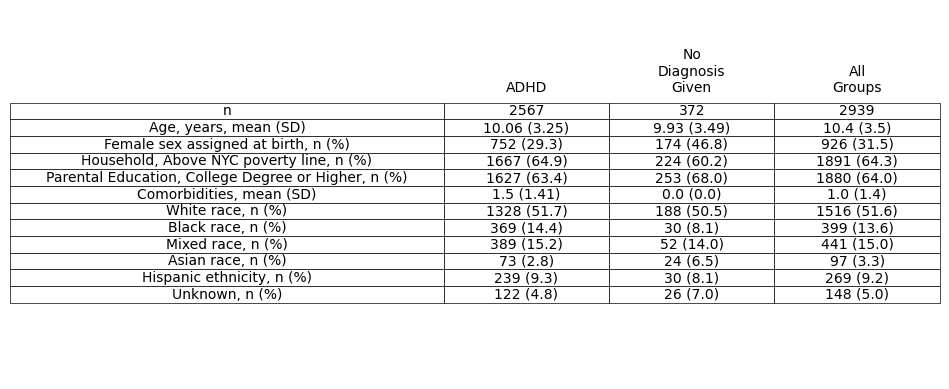

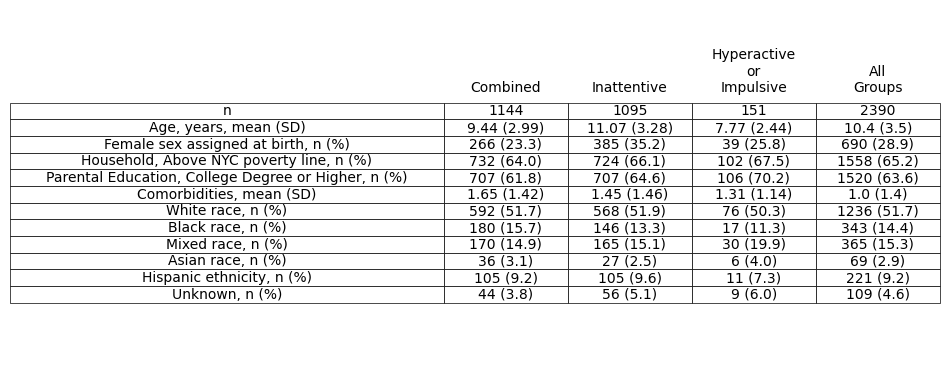

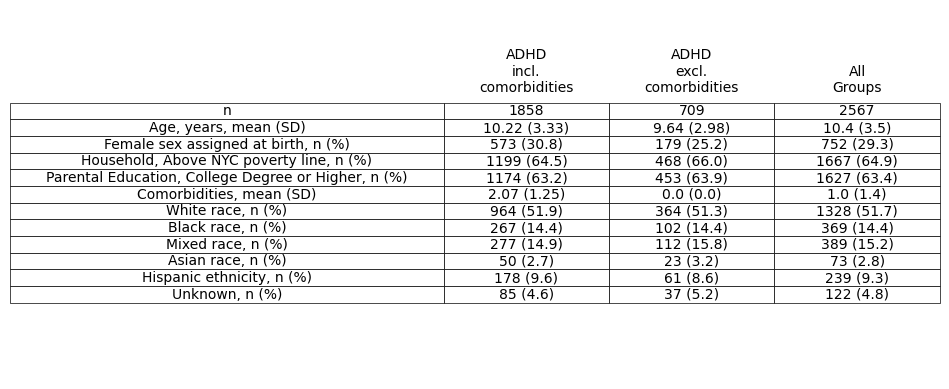

In [14]:
from hbn.visualization.make_tables import make_table_1
import pandas as pd
import os
from hbn.constants import Defaults

make_table_1(df,
             split='DX_Cat_Name_New', 
             split_vals=['ADHD', 'No Diagnosis Given']
             )

make_table_1(df,
            split='DX_Subtype_Name', 
            split_vals=['ADHD-Combined Type', 'ADHD-Inattentive Type', 'ADHD-Hyperactive/Impulsive Type'],
            split_val_new_names=['Combined', 'Inattentive', 'Hyperactive or Impulsive', 'All Groups']
            )

make_table_1(df,
            split='DX_ADHD', 
            split_vals=['adhd_all_comorbidities', 'adhd_no_comorbidities'],
            split_val_new_names=['ADHD incl. comorbidities', 'ADHD excl. comorbidities', 'All Groups']
            )

# make_table_1(df,
#              split='DX_Depression', 
#              split_vals=['No Diagnosis Given', 'ADHD-Combined Type (no Depression)',
#                         'ADHD-Inattentive Type (no Depression)', 'other_diagnoses',
#                         'Depression (no ADHD)']
#              )

# make_table_1(df,
#             split='DX_Anxiety', 
#             split_vals=['No Diagnosis Given', 'ADHD-Combined Type (no Anxiety)',
#                         'other_diagnoses', 'ADHD-Inattentive Type (no Anxiety)',
#                         'Anxiety (no ADHD)']
#             )

## Calculate Slopes x Sex for ADHD Subtypes
* Results: Relative to all possible ADHD diagnoses, ADHD Combined Type diagnosis decreases with age, while inattentive type increases with age (true for both boys and girls)

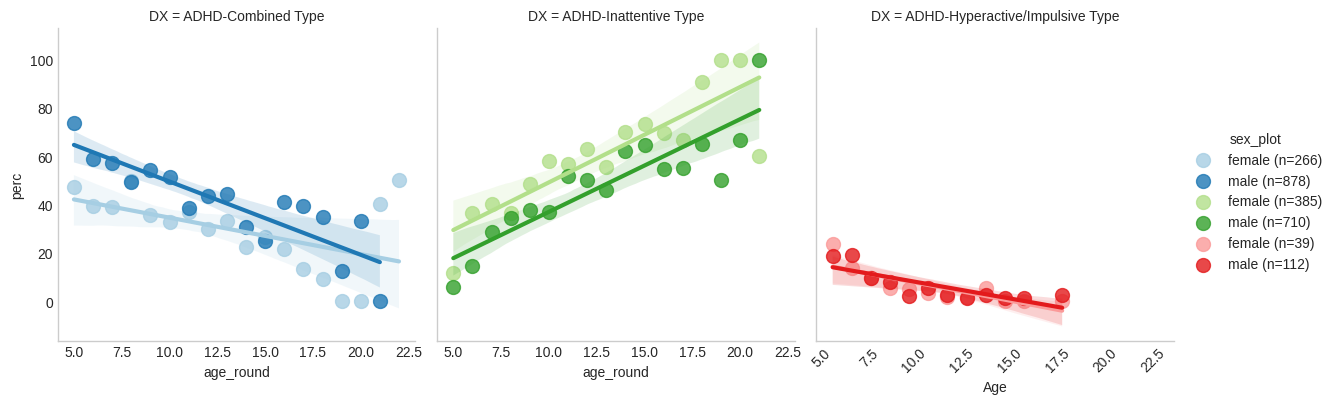

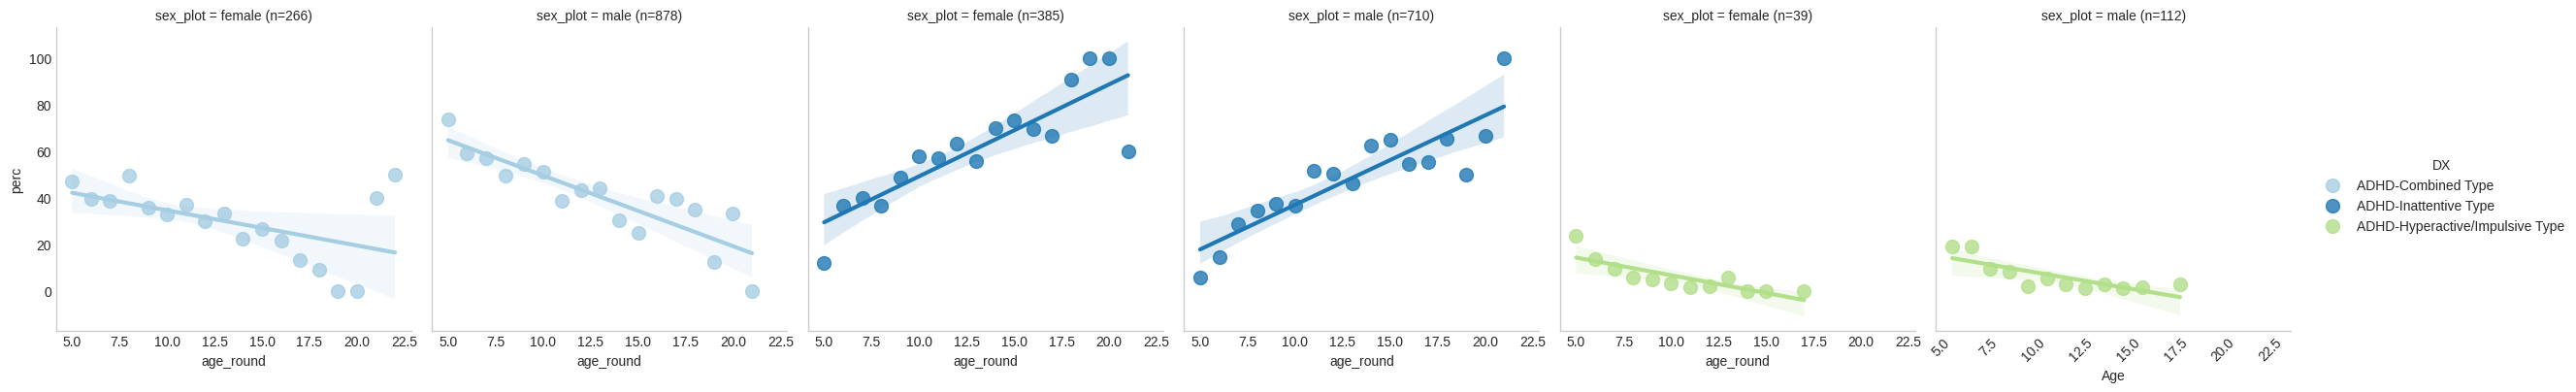

In [ ]:
vis.plotting_style()

overall_group = {'DX_Cat_Name_New': ['ADHD'],
                 'age_round': list(np.arange(6,18))
                 }

compare_groups = [{'DX_Subtype_Name': ['ADHD-Combined Type']},
                  {'DX_Subtype_Name': ['ADHD-Inattentive Type']},
                  {'DX_Subtype_Name': ['ADHD-Hyperactive/Impulsive Type']},
                  ]

df_perc_all = pd.DataFrame()
for group in compare_groups:
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group)
    df_perc['DX'] = group['DX_Subtype_Name'][0]
    df_perc_all = pd.concat([df_perc_all, df_perc])      

vis.plot_slopes(df_perc_all, ylabel=None, col='DX', hue='sex_plot', height=4, aspect=1)
vis.plot_slopes(df_perc_all, ylabel=None, col='sex_plot', hue='DX', height=4, aspect=1)


## Calculate Slopes x Sex for ADHD Comorbidities
* % of males with no ADHD comorbidities stays relatively flat across age (relative to males with all possible ADHD diagnoses), whereas the slope decreases steadily for females with no comorbodities (relative to females with all possible ADHD diagnoses)

* Interpretation: Young girls are more likely than older girls to have an ADHD diagnosis (without other comorbidities), but as girls get older, their likelihood of being diagnosed with ADHD + comorbidities sharply increases (whereas this is not the case for boys)

Does this mean that for a girl to be diagnosed with ADHD (no comorbidities) early in life, her symptoms must be pretty severe (or noticeable to parents/clinicians)?

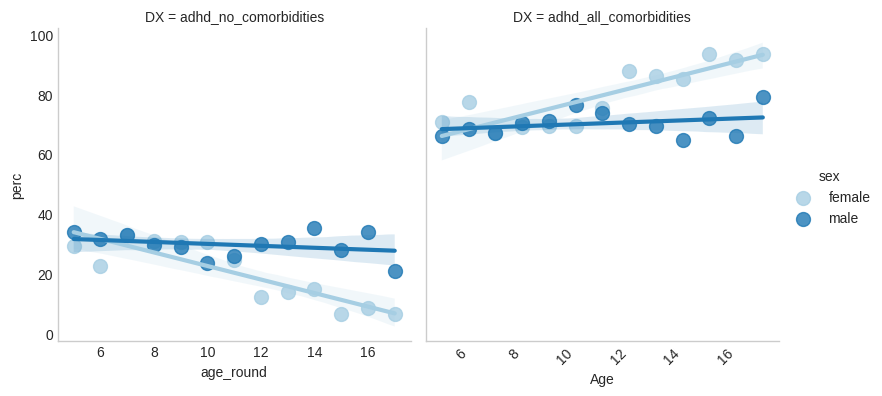

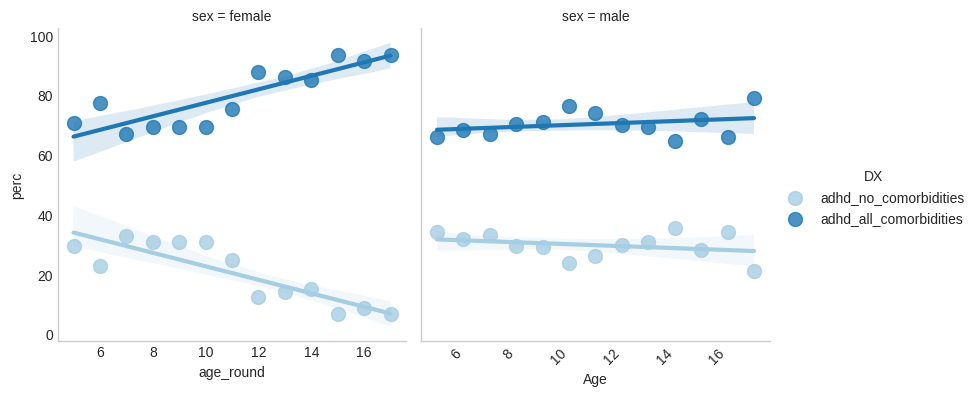

In [ ]:
vis.plotting_style()

overall_group = {'DX_Cat_Name_New': ['ADHD'],
                 'age_round': list(np.arange(6,18))}

compare_groups = [{'DX_ADHD': ['adhd_no_comorbidities']},
                  {'DX_ADHD': ['adhd_all_comorbidities']},
                  ]

df_perc_all = pd.DataFrame()
for group in compare_groups:
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group)
    df_perc['DX'] = group['DX_ADHD'][0]
    df_perc_all = pd.concat([df_perc_all, df_perc])      

vis.plot_slopes(df_perc_all, ylabel=None, col='DX', hue='sex', height=4, aspect=1)
vis.plot_slopes(df_perc_all, ylabel=None, col='sex', hue='DX', height=4, aspect=1)


## Calculate Slopes x Sex for Other diagnoses

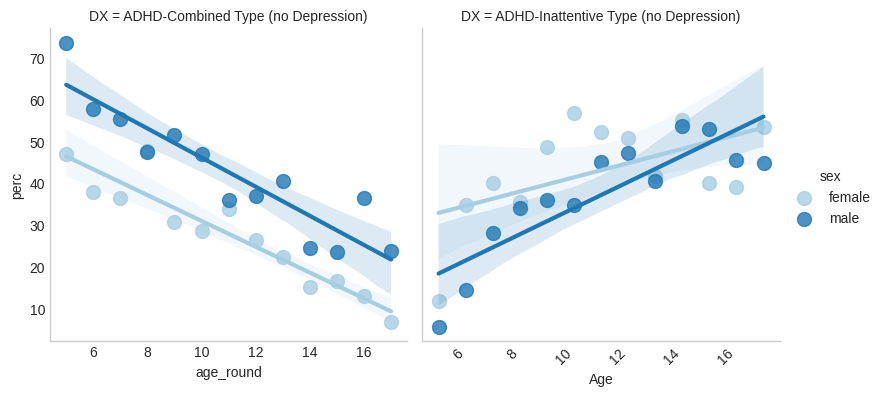

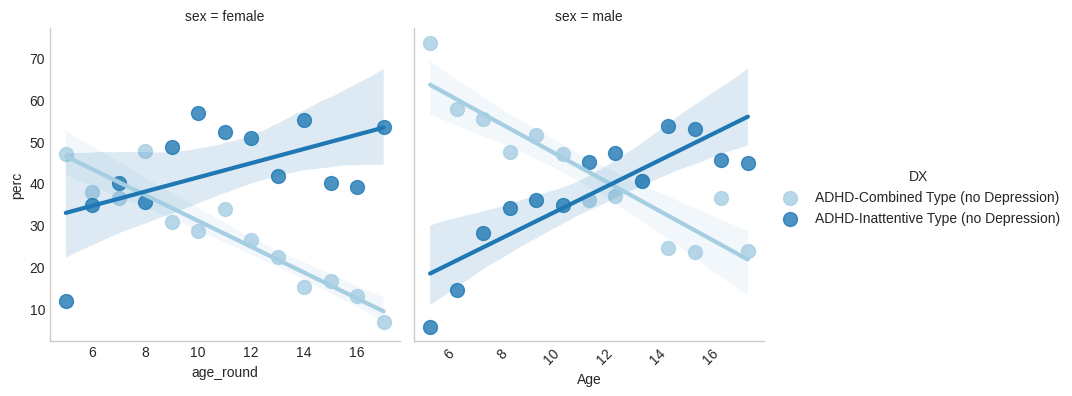

In [ ]:
vis.plotting_style()

overall_group = {'DX_Cat_Name_New': ['ADHD'],
                 'age_round': list(np.arange(6,18))}

compare_groups = [{'DX_Depression': ['ADHD-Combined Type (no Depression)']},
                  {'DX_Depression': ['ADHD-Inattentive Type (no Depression)']},
                  ]

df_perc_all = pd.DataFrame()
for group in compare_groups:
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group)
    df_perc['DX'] = group['DX_Depression'][0]
    df_perc_all = pd.concat([df_perc_all, df_perc])      

vis.plot_slopes(df_perc_all, ylabel=None, col='DX', hue='sex', height=4, aspect=1)
vis.plot_slopes(df_perc_all, ylabel=None, col='sex', hue='DX', height=4, aspect=1)


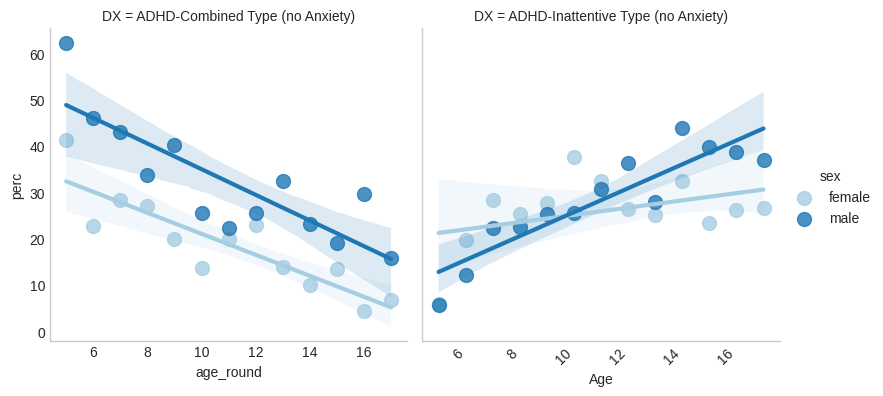

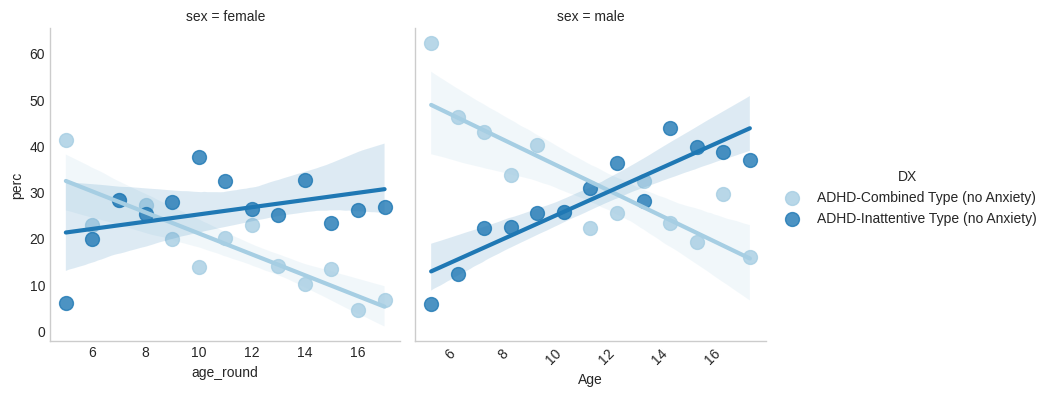

In [ ]:
vis.plotting_style()

overall_group = {'DX_Cat_Name_New': ['ADHD'],
                 'age_round': list(np.arange(6,18))}

compare_groups = [{'DX_Anxiety': ['ADHD-Combined Type (no Anxiety)']},
                  {'DX_Anxiety': ['ADHD-Inattentive Type (no Anxiety)']},
                  ]

df_perc_all = pd.DataFrame()
for group in compare_groups:
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group)
    df_perc['DX'] = group['DX_Anxiety'][0]
    df_perc_all = pd.concat([df_perc_all, df_perc])      

vis.plot_slopes(df_perc_all, ylabel=None, col='DX', hue='sex', height=4, aspect=1)
vis.plot_slopes(df_perc_all, ylabel=None, col='sex', hue='DX', height=4, aspect=1)



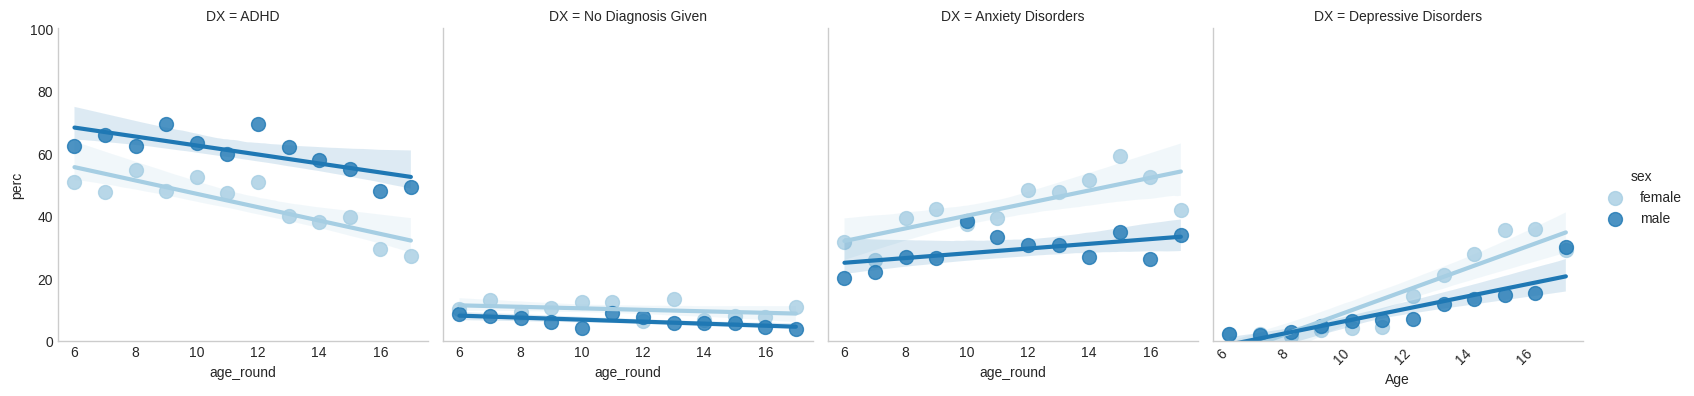

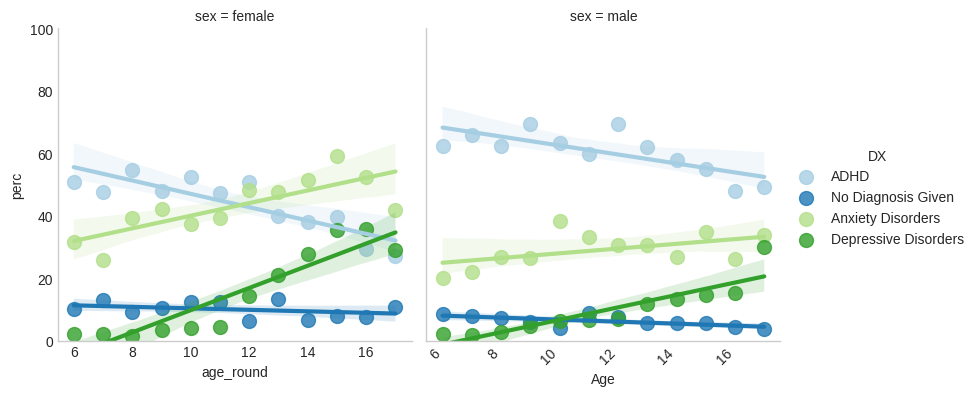

In [3]:
vis.plotting_style()

# grab all diagnoses
all_diagnoses = df[df['DX_Cat_Name_New'].notna()]['DX_Cat_Name_New'].unique().tolist()

overall_group = {'DX_Cat_Name_New': all_diagnoses,
                 'age_round': list(np.arange(6,18))}

compare_groups = [{'DX_Cat_Name_New': ['ADHD']},
                  {'DX_Cat_Name_New': ['No Diagnosis Given']},  
                  {'DX_Cat_Name_New': ['Anxiety Disorders']},
                  {'DX_Cat_Name_New': ['Depressive Disorders']},
                  ]

df_perc_all = pd.DataFrame()
for group in compare_groups:
    group.update({'age_round': list(np.arange(6,18))})
    df_perc = vis.calculate_slopes(df, group, overall_group)
    df_perc['DX'] = group['DX_Cat_Name_New'][0]
    df_perc_all = pd.concat([df_perc_all, df_perc])      

vis.plot_slopes(df_perc_all, ylabel=None, col='DX', hue='sex', height=4, aspect=1)
vis.plot_slopes(df_perc_all, ylabel=None, col='sex', hue='DX', height=4, aspect=1)
